In [13]:
import os
print(os.listdir())
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

['.ipynb_checkpoints', 'zomato analysis.ipynb', 'zomato.csv']


In [46]:
import pandas as pd
data = pd.read_csv('zomato.csv', encoding='latin-1')
df = data.copy()
df.head()
df.info()

# Objective:
# To analyze restaurant performance and identify factors affecting ratings,
# popularity, and pricing using feature engineering.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [33]:
# checking data qulity
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [34]:
# 1. Fill missing Cuisines with 'Other' 
data['Cuisines'] = data['Cuisines'].fillna('other')
# 2. Fix the 0 costs: Replace 0 with the Median of the whole dataset
median_cost = data['Average Cost for two'].median()
data['Average Cost for two'] = data['Average Cost for two'].replace(0,median_cost)
# Insight:
# Handling missing cuisines preserves dataset completeness,
# while replacing zero cost values with the median prevents skewed pricing analysis,
# ensuring more reliable insights in downstream calculations.

In [54]:
#  Create Cost per Person
df['Cost_per_person'] = df['Average Cost for two'] / 2
#  Create a 'Popularity' flag (True if votes are above average)
avg_votes = df['Votes'].mean()
df['Is_Popular'] = df['Votes'] > avg_votes

# Check your new columns
df[['Restaurant Name', 'Cost_per_person', 'Is_Popular']].head()
# Insight:
# Cost per person standardizes pricing for better comparison,
# while the popularity flag highlights restaurants with higher-than-average customer engagement,
# enabling identification of high-performing establishments.

,Restaurant Name,Cost_per_person,Is_Popular
0,Le Petit Souffle,550.0,True
1,Izakaya Kikufuji,600.0,True
2,Heat - Edsa Shangri-La,2000.0,True
3,Ooma,750.0,True
4,Sambo Kojin,750.0,True


In [ ]:
# Task: Create Rating Bins
bins = [0, 2, 3.5, 4.5, 5]
labels = ['Poor', 'Average', 'Good', 'Excellent']
df['Rating_Cat'] = pd.cut(df['Aggregate rating'], bins=bins, labels=labels)
# Insight:
# Rating categorization reveals that the majority of restaurants cluster in mid-quality segments,
# while fewer achieve 'Excellent' ratings, highlighting the difficulty of maintaining top-tier quality.

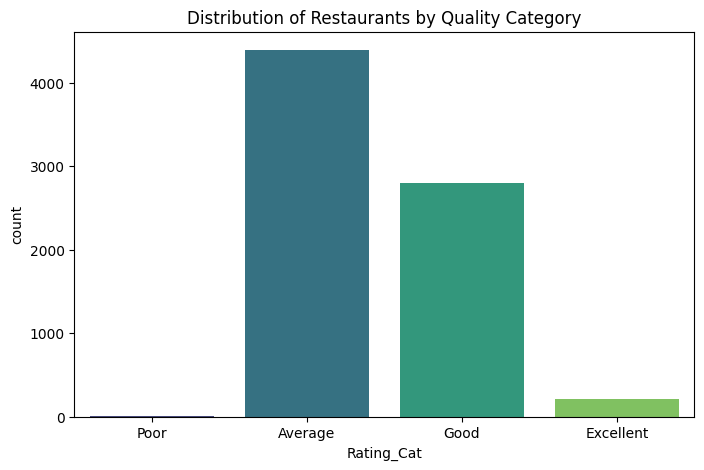

In [55]:
# VERIFICATION PLOT 1: Count of restaurants in each bin
plt.figure(figsize=(8,5))
sns.countplot(x='Rating_Cat', data=df, hue='Rating_Cat', palette='viridis', legend=False)
plt.title('Distribution of Restaurants by Quality Category')
plt.savefig('01_rating_bins_count.png')
plt.show()

# Insight:
# Most restaurants fall into the 'Good' and 'Average' categories,
# indicating a competitive market where few restaurants achieve 'Excellent' ratings.

In [38]:
# Task: One-Hot Encoding for 'Has Online delivery'
# This creates a column where 1 = Yes and 0 = No
df = pd.get_dummies(df, columns=['Has Online delivery'], drop_first=True)

# Task: Label Encoding for Rating_Cat
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Rating_Score'] = le.fit_transform(df['Rating_Cat'].astype(str))
# Insight:
# Encoding categorical variables transforms them into numerical form,
# enabling their use in analysis and modeling.
# Online delivery is converted into a binary feature,
# while rating categories are converted into ordered scores for comparison.

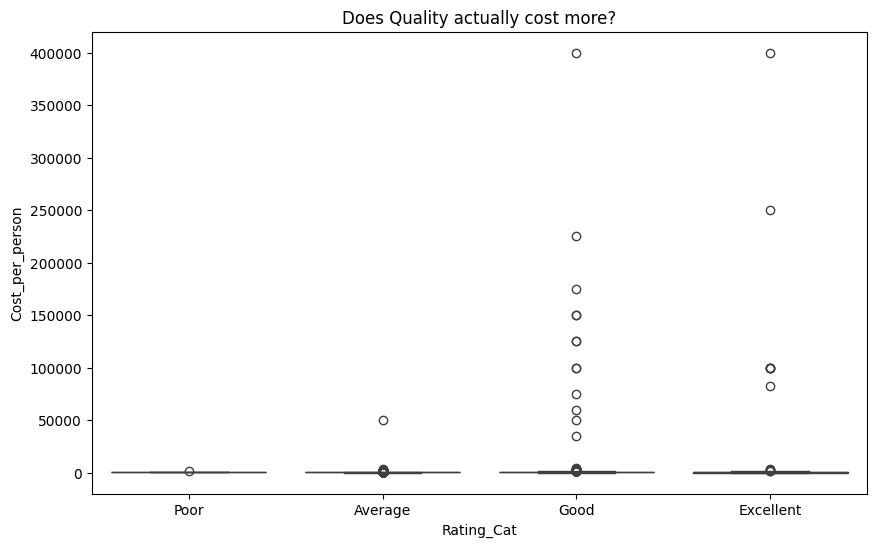

In [39]:
# 1. Find the average cost for every city
city_avg = df.groupby('City')['Average Cost for two'].transform('mean')

# 2. Create feature: Is it overpriced for its location?
df['Relative_Cost_Status'] = df['Average Cost for two'] > city_avg
# Insight:
# Relative cost status compares restaurant pricing within each city,
# identifying whether a restaurant is overpriced or affordable in its local context.
# This helps normalize pricing differences across cities.

# VERIFICATION PLOT 2: Relationship check
plt.figure(figsize=(10,6))
sns.boxplot(x='Rating_Cat', y='Cost_per_person', data=df)
plt.title('Does Quality actually cost more?')
plt.savefig('02_rating_vs_cost.png')
plt.show()
# Insight:
# Higher-rated restaurants tend to have slightly higher cost per person,
# but the overlap across categories shows that excellent quality does not always require high pricing.

In [40]:
# 1. Fill missing values with a string first
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

df['Cuisine_Count'] = df['Cuisines'].apply(lambda x: len(x.split(',')))
# Insight:
# Filling missing cuisine values ensures all records are retained,
# while counting the number of cuisines helps measure menu diversity,
# indicating whether a restaurant offers specialized or multi-cuisine options.

In [41]:
# Feature: Engagement relative to price
df['Engagement_Ratio'] = df['Votes'] / df['Average Cost for two']
# Insight:
# Engagement ratio measures customer interaction relative to pricing,
# helping identify restaurants that generate high interest despite their cost.
# It highlights value-for-money restaurants that attract strong customer attention.

In [42]:
# Feature: How many competitors are in the same locality?
df['Locality_Saturation'] = df.groupby('Locality')['Restaurant ID'].transform('count')
# Insight:
# Locality saturation measures the level of competition in a given area
# by counting the number of restaurants present,
# helping identify highly competitive versus less crowded markets.

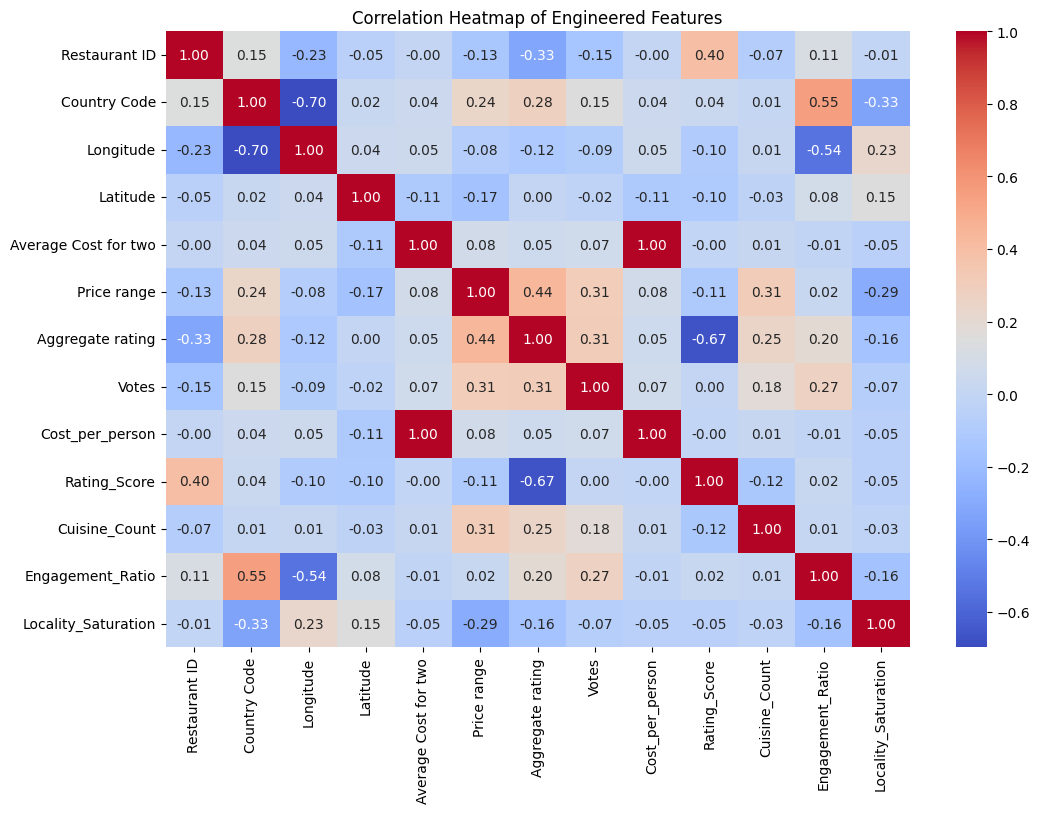

In [43]:
# Selecting only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64', 'uint8']).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Engineered Features')
plt.savefig('03_correlation_heatmap.png')
plt.show()
# Insight:
# The correlation heatmap reveals relationships between numerical features,
# showing that customer engagement (votes) is positively correlated with popularity-related features,
# while cost shows weaker correlation with ratings,
# indicating that higher price does not necessarily lead to better customer satisfaction.


Final Conclusion


- Restaurant success is driven more by customer engagement than pricing,
 as higher votes and engagement ratios show stronger influence on performance.

- Cost does not strongly correlate with ratings,
 indicating that expensive restaurants are not necessarily better rated.

- High-performing restaurants often deliver better value for money,
 balancing affordability with quality and customer experience.

- Market competition varies by locality,
 with highly saturated areas requiring stronger differentiation to succeed.

- Feature engineering (such as engagement ratio, cost per person, and locality saturation)
 reveals deeper insights that are not visible in raw data alone.